#### Ada Boost Regressor

It is a kind of ensemble supervised machine learning technique based on boosting.

It has multiple weak learners that are all combined to form a strong predictive model.

#### Algorithm used:----

1.  Each and every weak learner run simultaneously.

2.  Each weak learner makes predictions based on the data received. Some of the predictions may be incorrect.

3.  The incorrect predcitions are given more weights when passed to the next weak learner.

4.  This goes on unless and until all the incorrect predictions have been rectified.

5.  The final strong predictive model has the weighted sum of all the weak learners and the output is continuous in nature.


#### Step  1:  Import  all the necessary libraries

In [818]:
import  numpy               as  np
import  pandas              as  pd
import  matplotlib.pyplot   as  plt
import  seaborn             as  sns

from    sklearn.datasets        import  fetch_california_housing
from    sklearn.model_selection import  train_test_split, GridSearchCV, KFold
from    sklearn.preprocessing   import  StandardScaler
from    sklearn.pipeline        import  Pipeline
from    sklearn.tree            import  DecisionTreeRegressor
from    sklearn.ensemble        import  AdaBoostRegressor
from    sklearn.metrics         import  mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

#### Step 2: Load the dataset

In [819]:
#### extract the data

data = fetch_california_housing()

#### construct the dataframe from the data

df = pd.DataFrame(data.data, columns=data.feature_names)

#### Add the target to the data

df['MedHouseVal'] = data.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


#### OBSERVATIONS:

1.  The above dataset explains about the house price details of California for each and every record.

2.  The independent features in the dataset are as follows :----

    (a.)  MedInc ===============>  Median Income

    (b.)  HouseAge =============>  Median House Age

    (c.)  AveRooms =============>  Average number of rooms per household

    (d.)  Population ============> Total population in a district

    (e.)  AveOccup ==============>  Average Occupation per household

    (f.)  Latitude ==============>  Geographical Latitude

    (g.)  Longitude ==============> Geographical longitude

3. The dependent feature of the dataset is MedHouseVal

    (a.)  MedHouseVal =============> Median House Value (House Price)

#### Step 3:  Peform Data Exploration

In [820]:
#### get the top five rows of the dataset

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [821]:
#### get the bottom five rows of the dataset

df.tail()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847
20639,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24,0.894


In [822]:
#### get the length of the dataset

print("Length of the dataset is:", len(df))

Length of the dataset is: 20640


In [823]:
#### get the shape of the dataset

print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (20640, 9)


In [824]:
#### get the column used in the dataset

df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

In [825]:
#### get the information about the columns used in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


#### OBSERVATIONS:

1.  All the columns are floating point in nature.

In [826]:
#### get the descriptive summary statistics about each column in the dataset

df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


#### OBSERVATIONS:

1.  The above table depicts about the statistical information for each numerical column in the dataset.

In [827]:
#### get the correlation between all the numerical column in the dataset

df.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


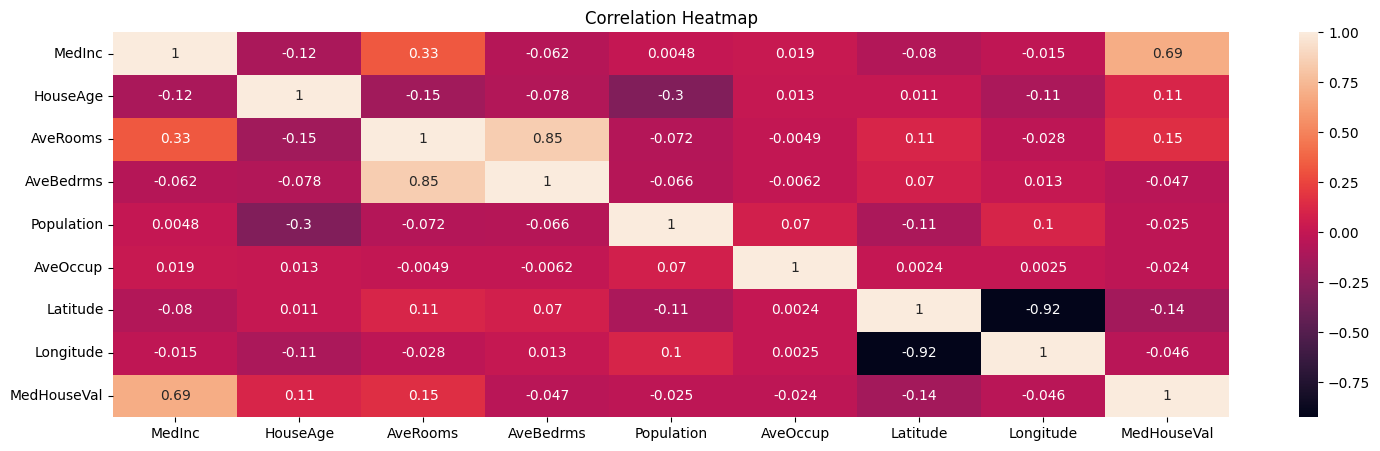

In [828]:
#### get the graphical representation for correlation between all the numerical column in the dataset

plt.figure(figsize=(18,5))
sns.heatmap(df.corr(),annot=True)
plt.title("Correlation Heatmap")
plt.show()

#### OBSERVATIONS:

1.  The above graph depicts the Correlation Heatmap.

2.  It explains about the correlation between each numerical column with respect to the other in the dataset.

#### Step 4: Perform Data Cleaning and Feature Engineering

In [829]:
#### To check for the NULL records in the dataset

df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL records in the dataset.

In [830]:
#### To check for the duplicate records in the dataset

df[df.duplicated()]

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal


#### OBSERVATIONS:

1.  There are no duplicate records in the dataset.

#### Step 5: Divide the dataset into independent and dependent features

In [831]:
#### independent features

X = df.drop(columns='MedHouseVal',axis=1)

print(X)

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  
0        -122.23  
1

In [832]:
#### dependent features

Y = df['MedHouseVal']

print(Y)

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: MedHouseVal, Length: 20640, dtype: float64


#### Step 6: Divide the independent and dependent features into training and testing data

In [833]:
from  sklearn.model_selection   import  train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [834]:
X_train

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
14196,3.2596,33.0,5.017657,1.006421,2300.0,3.691814,32.71,-117.03
8267,3.8125,49.0,4.473545,1.041005,1314.0,1.738095,33.77,-118.16
17445,4.1563,4.0,5.645833,0.985119,915.0,2.723214,34.66,-120.48
14265,1.9425,36.0,4.002817,1.033803,1418.0,3.994366,32.69,-117.11
2271,3.5542,43.0,6.268421,1.134211,874.0,2.300000,36.78,-119.80
...,...,...,...,...,...,...,...,...
11284,6.3700,35.0,6.129032,0.926267,658.0,3.032258,33.78,-117.96
11964,3.0500,33.0,6.868597,1.269488,1753.0,3.904232,34.02,-117.43
5390,2.9344,36.0,3.986717,1.079696,1756.0,3.332068,34.03,-118.38
860,5.7192,15.0,6.395349,1.067979,1777.0,3.178891,37.58,-121.96


In [835]:
X_test

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
20046,1.6812,25.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01
3024,2.5313,30.0,5.039384,1.193493,1565.0,2.679795,35.14,-119.46
15663,3.4801,52.0,3.977155,1.185877,1310.0,1.360332,37.80,-122.44
20484,5.7376,17.0,6.163636,1.020202,1705.0,3.444444,34.28,-118.72
9814,3.7250,34.0,5.492991,1.028037,1063.0,2.483645,36.62,-121.93
...,...,...,...,...,...,...,...,...
15362,4.6050,16.0,7.002212,1.066372,1351.0,2.988938,33.36,-117.22
16623,2.7266,28.0,6.131915,1.256738,1650.0,2.340426,35.36,-120.83
18086,9.2298,25.0,7.237676,0.947183,1585.0,2.790493,37.31,-122.05
2144,2.7850,36.0,5.289030,0.983122,1227.0,2.588608,36.77,-119.76


In [836]:
print("Shape of the input training data is:", X_train.shape)
print("Shape of the input testing data  is:", X_test.shape)

Shape of the input training data is: (16512, 8)
Shape of the input testing data  is: (4128, 8)


In [837]:
Y_train

14196    1.030
8267     3.821
17445    1.726
14265    0.934
2271     0.965
         ...  
11284    2.292
11964    0.978
5390     2.221
860      2.835
15795    3.250
Name: MedHouseVal, Length: 16512, dtype: float64

In [838]:
Y_test

20046    0.47700
3024     0.45800
15663    5.00001
20484    2.18600
9814     2.78000
          ...   
15362    2.63300
16623    2.66800
18086    5.00001
2144     0.72300
3665     1.51500
Name: MedHouseVal, Length: 4128, dtype: float64

In [839]:
print("Shape of the output training data is:", Y_train.shape)
print("Shape of the output testing data  is:", Y_test.shape)

Shape of the output training data is: (16512,)
Shape of the output testing data  is: (4128,)


#### Step 7: Perform Feature Scaling on the inputs

In [840]:
from  sklearn.preprocessing import StandardScaler

#### create an object for Standard Scaler

sc = StandardScaler()

#### using the object for Standard Scaler, transform the inputs

X_train_scaled = sc.fit_transform(X_train)

In [841]:
X_train_scaled

array([[-0.326196  ,  0.34849025, -0.17491646, ...,  0.05137609,
        -1.3728112 ,  1.27258656],
       [-0.03584338,  1.61811813, -0.40283542, ..., -0.11736222,
        -0.87669601,  0.70916212],
       [ 0.14470145, -1.95271028,  0.08821601, ..., -0.03227969,
        -0.46014647, -0.44760309],
       ...,
       [-0.49697313,  0.58654547, -0.60675918, ...,  0.02030568,
        -0.75500738,  0.59946887],
       [ 0.96545045, -1.07984112,  0.40217517, ...,  0.00707608,
         0.90651045, -1.18553953],
       [-0.68544764,  1.85617335, -0.85144571, ..., -0.08535429,
         0.99543676, -1.41489815]])

In [842]:
X_test_scaled = sc.transform(X_test)

In [843]:
X_test_scaled

array([[-1.15508475, -0.28632369, -0.52068576, ...,  0.06740798,
         0.1951    ,  0.28534728],
       [-0.70865905,  0.11043502, -0.16581537, ..., -0.03602975,
        -0.23549054,  0.06097472],
       [-0.21040155,  1.85617335, -0.61076476, ..., -0.14998876,
         1.00947776, -1.42487026],
       ...,
       [ 2.80902421, -0.28632369,  0.75501156, ..., -0.02646898,
         0.78014149, -1.23041404],
       [-0.57542978,  0.58654547, -0.06124296, ..., -0.04390537,
         0.52740357, -0.08860699],
       [-0.17259111, -0.92113763, -0.6058703 , ...,  0.05466644,
        -0.66608108,  0.60445493]])

#### OBSERVATIONS:

1.  All the inputs have been transformed in the same scale range between -1 to 1.

#### Step 8: Train the Ada Boost Regressor Model

In [844]:
#### Construct the weak learner

from sklearn.tree import DecisionTreeRegressor

base_estimator = DecisionTreeRegressor(
    max_depth   =   1                   ,
    random_state = 42
)

#### OBSERVATIONS:

1.  The AdaBoost Regressor model has multiple weak learners combined together to form a strong predictive model.

2.  These weak learners have a decision tree stump with a depth of 1.

3.  For constructing a AdaBoost Regressor, we must create a Decision Tree at first with a depth of 1.

In [845]:
#### Construct the Ada Boost Regressor Model

adareg = AdaBoostRegressor(
    estimator       =       base_estimator              ,
    n_estimators    =           50                      ,
    learning_rate   =           0.1                     ,
    random_state    =           42
)

In [846]:
#### With the help of the object for Ada Boost Regressor, train the model

adareg.fit(X_train_scaled, Y_train)

AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=1, random_state=42),
                  learning_rate=0.1, random_state=42)

#### Step 9: Predict the Ada Boost Regressor Model

In [847]:
Y_pred = adareg.predict(X_test_scaled)

In [848]:
Y_pred

array([1.78899596, 1.78899596, 1.95092264, ..., 3.31981822, 1.78899596,
       2.01537112])

#### Step 10: Evaluate the Regression Metrics

In [849]:
from    sklearn.metrics             import   mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

print("==============================Mean Absolute Error========================================================")

mae = mean_absolute_error(Y_test, Y_pred)

print("Mean Absolute Error of the model is:", mae)


print("==============================Mean Squared Error========================================================")

mse = mean_squared_error(Y_test, Y_pred)

print("Mean Squared Error of the model is:", mse)


print("==============================Root Mean Squared Error========================================================")

rmse = root_mean_squared_error(Y_test, Y_pred)

print("Root Mean Squared Error of the model is:", rmse)


print("==============================R2 Score========================================================")

r2 = r2_score(Y_test, Y_pred)

print("R2 Score of the model is:", r2)

==============================Mean Absolute Error========================================================
Mean Absolute Error of the model is: 0.7322967378633417
==============================Mean Squared Error========================================================
Mean Squared Error of the model is: 0.8326644176789035
==============================Root Mean Squared Error========================================================
Root Mean Squared Error of the model is: 0.9125044754295201
==============================R2 Score========================================================
R2 Score of the model is: 0.36457668445108116


#### OBSERVATIONS:

1.  The R2 Score of the Ada Boost Regressor Model using California Housing dataset is 0.36.

2.  The R2 Score is very less, but it can further be improved using Hyper Parameter Tuning using GridSerachCV.

#### Step 11: Predict the House Price for a given sample data

In [850]:
df.iloc[[0]]

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.02381,322.0,2.555556,37.88,-122.23,4.526


In [851]:
X.iloc[[0]]

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.02381,322.0,2.555556,37.88,-122.23


In [852]:
#### define the sample data

sample = X.iloc[[0]]

print(sample)


#### perform scaling on the sample data

scaled_data = sc.transform(sample)

print(scaled_data)

#### perform the prediction on the scaled data

prediction = adareg.predict(scaled_data)

print(prediction)

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127    1.02381       322.0  2.555556     37.88   

   Longitude  
0    -122.23  
[[ 2.33397811  0.98330419  0.64880421 -0.1682248  -0.97135592 -0.04676
   1.04692041 -1.32016306]]
[3.31981822]


#### Step 12: Visualizing the Feature Importances

[0.96807701 0.         0.         0.         0.         0.03192299
 0.         0.        ]
[0 5 6 7 4 3 2 1]
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')


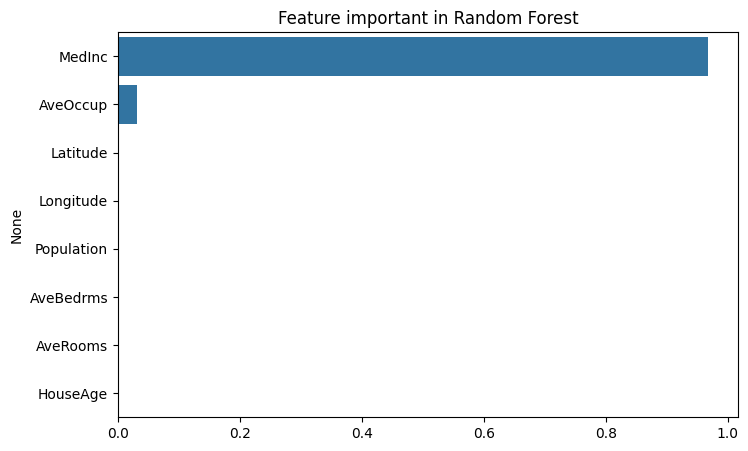

In [853]:
#### extract all the important features from the dataset

features = adareg.feature_importances_

print(features)


#### sort all the important features in the descending order of their indices

indices = np.argsort(features)[::-1]

print(indices)


#### extract all the columns from the dataset

res = X.columns

print(res)


#### Plot all the important features in the dataset
plt.figure(figsize=(8,5))
sns.barplot(x=features[indices], y=res[indices])
plt.title("Feature important in Random Forest")
plt.show()

#### OBSERVATIONS:

1.  "MedInc" is the feature that is having the highest feature importance. So it is the most important feature.

2.  "HouseAge" is the feature that is having the lowest feature importance. So it is the least important feature.

#### Step 13: Perform Hyper Parameter Tuning with GridSearchCV

In [854]:
#### define the pipeline

from sklearn.pipeline  import  Pipeline

#### create an object for Pipeline

pipeline    =   Pipeline([
    ("sc"       ,       StandardScaler())           ,
    ("adareg"   ,       AdaBoostRegressor(
        estimator   =   DecisionTreeRegressor(
            random_state = 42
        )
    ))
])


In [855]:
#### define the param grid

param_grid = {
    #### Define the decision tree parameters
    "adareg__estimator__max_depth"          :       [1,3,5,7,9]         ,
    "adareg__estimator__min_samples_leaf"   :       [2,5,10]            ,
    "adareg__estimator__min_samples_split"  :       [1,2,4]             ,

   #### Define the Ada Boost Parameters
   "adareg__n_estimators"                   :       [10,20,30]        ,
   "adareg__learning_rate"                  :       [0.01,0.1,1]        ,
   "adareg__loss"                           :       ["linear","square","exponential"]
}

In [856]:
#### perform the KFold Validation

cv = KFold(n_splits = 3, shuffle =True, random_state = 42)

In [857]:
#### create the object for GridSearchCV

grid = GridSearchCV(
    pipeline                                ,
    param_grid      =       param_grid      ,
    cv              =           cv          ,
    scoring         =         'r2'          ,
    n_jobs          =          -1 
)

In [858]:
#### using the object for GridSearchCV, train the model

grid.fit(X_train, Y_train)

c:\Users\DELL\Desktop\Complete_Data_Science\vens\lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
1215 fits failed out of a total of 3645.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1215 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\DELL\Desktop\Complete_Data_Science\vens\lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\DELL\Desktop\Complete_Data_Science\vens\lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\DELL\Desktop\Complete_Data_Science\vens\lib\site-packages\sklearn\pipeline

GridSearchCV(cv=KFold(n_splits=3, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('sc', StandardScaler()),
                                       ('adareg',
                                        AdaBoostRegressor(estimator=DecisionTreeRegressor(random_state=42)))]),
             n_jobs=-1,
             param_grid={'adareg__estimator__max_depth': [1, 3, 5, 7, 9],
                         'adareg__estimator__min_samples_leaf': [2, 5, 10],
                         'adareg__estimator__min_samples_split': [1, 2, 4],
                         'adareg__learning_rate': [0.01, 0.1, 1],
                         'adareg__loss': ['linear', 'square', 'exponential'],
                         'adareg__n_estimators': [10, 20, 30]},
             scoring='r2')

In [859]:
#### Obtain the best parameters and the estimator of the model

best_parameter = grid.best_params_
print("Best Parameters of the model is:", best_parameter)


best_estimator = grid.best_estimator_
print("Best Estimator of the model is:", best_estimator)

Best Parameters of the model is: {'adareg__estimator__max_depth': 9, 'adareg__estimator__min_samples_leaf': 2, 'adareg__estimator__min_samples_split': 2, 'adareg__learning_rate': 1, 'adareg__loss': 'square', 'adareg__n_estimators': 30}
Best Estimator of the model is: Pipeline(steps=[('sc', StandardScaler()),
                ('adareg',
                 AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=9,
                                                                   min_samples_leaf=2,
                                                                   random_state=42),
                                   learning_rate=1, loss='square',
                                   n_estimators=30))])


In [860]:
#### predict the model

Y_pred_grid = best_estimator.predict(X_test)

In [861]:
##### Evaluate the Regression Metrics

from    sklearn.metrics             import   mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score


print("==============================Mean Absolute Error========================================================")

maegrid = mean_absolute_error(Y_test, Y_pred_grid)

print("Mean Absolute Error of the model is:", maegrid)



print("==============================Mean Squared Error========================================================")

msegrid = mean_squared_error(Y_test, Y_pred_grid)

print("Mean Squared Error of the model is:", msegrid)



print("==============================Root Mean Squared Error========================================================")

rmsegrid = root_mean_squared_error(Y_test, Y_pred_grid)

print("Root Mean Squared Error of the model is:", rmsegrid)


print("==============================R2 Score========================================================")

r2grid = r2_score(Y_test, Y_pred_grid)

print("R2 Score of the model is:", r2grid)

==============================Mean Absolute Error========================================================
Mean Absolute Error of the model is: 0.3899102293358757
==============================Mean Squared Error========================================================
Mean Squared Error of the model is: 0.2833595578142852
==============================Root Mean Squared Error========================================================
Root Mean Squared Error of the model is: 0.5323152804628899
==============================R2 Score========================================================
R2 Score of the model is: 0.7837625027610322


#### OBSERVATIONS:

1.  The R2 Score of the Ada Boost Regressor Model using California Housing dataset after perfroming Hyper Parameter Tuning with GridSearchCV is 0.78.

2.  The R2 Score has improved from 0.36 to 0.78 by using Hyper Parameter Tuning using GridSerachCV.

#### Step 14: Predict the House Price for a given sample data after performing hyper parameter tuning with GridSearchCV

In [862]:
#### define the sample data

sample = X.iloc[[0]]

#### perform the prediction on the sample data

prediction = best_estimator.predict(sample)

print("Predicted House Price of the dataset is:", prediction)

Predicted House Price of the dataset is: [4.26791917]


[0.21085453 0.07436341 0.09103014 0.06370613 0.08814255 0.12715626
 0.16436909 0.18037788]
[0 7 6 5 2 4 1 3]
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')


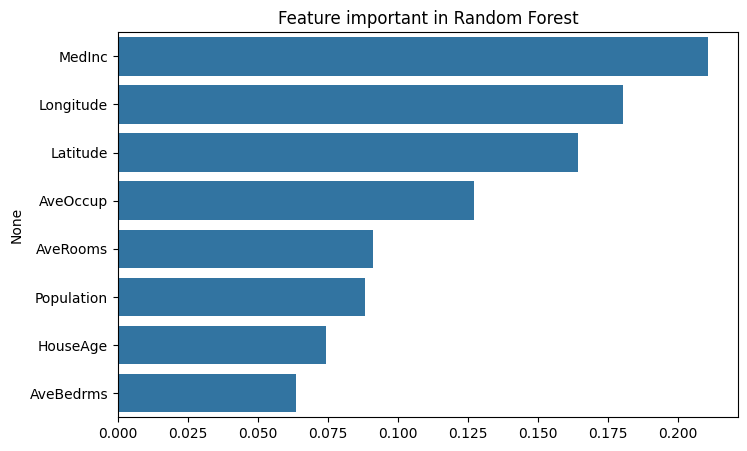

In [863]:
#### extract all the important features from the dataset
adaregmodel = best_estimator.named_steps["adareg"]

features = adaregmodel.feature_importances_

print(features)


#### sort all the important features in the descending order of their indices

indices = np.argsort(features)[::-1]

print(indices)


#### extract all the columns from the dataset

res = X.columns

print(res)


#### Plot all the important features in the dataset
plt.figure(figsize=(8,5))
sns.barplot(x=features[indices], y=res[indices])
plt.title("Feature important in Random Forest")
plt.show()

#### OBSERVATIONS:

1.  "MedInc" is the feature that is having the highest feature importance after performing hyper parameter tuning with GridSearchCV. So it is the most important feature.

2.  "AveBedrms" is the feature that is having the lowest feature importance after performing hyper parameter tuning with GridSearchCV. So it is the least important feature.